In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import variance, stddev, col, count, isnan, when
from pyspark.sql.types import NumericType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.preprocessing import StandardScaler as SKStandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
fraud_channels =  ['API', 'ATM', 'BIO', 'BISP', 'Business App', 'Business App API', 'Cheetay', 'JC Keyboard', 'Merchant Payment', 'Mobile App', 'NEW_JC_APP', 'PAYPAK', 'PGW', 'Payment Gateway', 'QR Payment', 'Self Care App', 'THIRD_PARTY_WEB', 'USSD', 'USSD API', 'USSD_API', 'VRG']
fraud_types =  ['Online Payment', 'PTS ATM Withdrawal', 'PTS Purchase Payment', 'Transfer(C2C)', 'MFS Card Withdraw', 'Cash in', 'Cash out', 'IBFT Outgoing Customer', 'IBFT Outgoing OTC', 'Merchant Payment', 'Transfer(B2C)', 'Transfer(C2B)', 'Jazz Load (Prepaid top-up)', 'Business Cash Out', 'Customer Remit To CNIC', 'Donation', 'Get Loan', 'IBFT Credit', 'Others', 'Utility Bills Payment', 'Purchase Payment', 'Auto Debit', 'Indigo Bills (Postpaid payment)']

channels_in_clause = ", ".join([f"'{ch}'" for ch in fraud_channels])
types_in_clause = ", ".join([f"'{tp}'" for tp in fraud_types])

CLICKHOUSE_CONFIG = {
    'host': 'localhost',
    'port': 9000,
    'database': 'public',
    'user': 'default',
    'password': 'DfsTeChB1'
}

url = f"jdbc:ch://{CLICKHOUSE_CONFIG['host']}:8123/{CLICKHOUSE_CONFIG['database']}"
user = CLICKHOUSE_CONFIG['user'] 
password = CLICKHOUSE_CONFIG['password']
driver = "com.clickhouse.jdbc.ClickHouseDriver"

packages = [
    "com.clickhouse.spark:clickhouse-spark-runtime-3.5_2.12:0.8.1",
    "com.clickhouse:clickhouse-client:0.9.4",
    "com.clickhouse:clickhouse-http-client:0.9.4",
    "org.apache.httpcomponents.client5:httpclient5:5.2.1"
]

spark = (SparkSession.builder
    .appName("poc-model-training")
    # .master("spark://10.205.161.118:7077")
    .master("local[*]")
    .config("spark.jars.packages", ",".join(packages))
    .config("spark.executor.memory", "150g")
    .config("spark.executor.memoryOverhead", "5g")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.cores", "32")
    .config("spark.executor.instances", "2")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.default.parallelism", "96")
    .getOrCreate()
)
    
# Configure ClickHouse catalog
spark.conf.set("spark.sql.catalog.clickhouse", "com.clickhouse.spark.ClickHouseCatalog")
spark.conf.set("spark.sql.catalog.clickhouse.host", "localhost")
spark.conf.set("spark.sql.catalog.clickhouse.protocol", "http")
spark.conf.set("spark.sql.catalog.clickhouse.http_port", "8123")
spark.conf.set("spark.sql.catalog.clickhouse.user", "default")
spark.conf.set("spark.sql.catalog.clickhouse.password", "DfsTeChB1")
spark.conf.set("spark.sql.catalog.clickhouse.database", "public")
spark.conf.set("spark.clickhouse.write.format", "json")           

:: loading settings :: url = jar:file:/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.clickhouse.spark#clickhouse-spark-runtime-3.5_2.12 added as a dependency
com.clickhouse#clickhouse-client added as a dependency
com.clickhouse#clickhouse-http-client added as a dependency
org.apache.httpcomponents.client5#httpclient5 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0e7f3085-edd8-4466-8c46-9192011856bb;1.0
	confs: [default]
	found com.clickhouse.spark#clickhouse-spark-runtime-3.5_2.12;0.8.1 in central
	found com.clickhouse#clickhouse-client;0.9.4 in central
	found com.clickhouse#clickhouse-data;0.9.4 in central
	found commons-codec#commons-codec;1.17.1 in central
	found commons-io#commons-io;2.16.1 in central
	found org.apache.commons#commons-lang3;3.18.0 in central
	found org.apache.commons#commons-compress;1.27.1 in central
	found com.clickhouse#clickhouse-http-client;0.9.4 in central
	found org.apache.httpcomponents.client5#http

# Data Extraction

In [3]:
TRAIN_START_DATE = '2025-06-01'
TRAIN_END_DATE = '2025-06-24'
TEST_START_DATE = '2025-06-25'
TEST_END_DATE = '2025-06-30'

In [4]:
selected_cols = [
'cutoff_date',
'fraud_flag',
 'trx_channel',
 'trx_type',
 'start_balance',
 'trx_amt',
 'mbar_registered_channel',
 'mbar_a_c_status',
 'mbar_a_c_level',
 'mbar_account_type_name',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'is_night',
 'is_business_hours',
 'is_unusual_hour',
 'night_weekend_combo',
 'start_balance_log',
 'txn_txns_3d',
 'txn_total_amount_3d',
 'txn_avg_amount_3d',
 'txn_max_amount_3d',
 'txn_min_amount_3d',
 'txn_unique_recipients_3d',
 'txn_unique_channels_3d',
 'txn_unique_types_3d',
 'txn_is_high_activity_3d',
 'txn_multi_channel_recent',
 'txn_amount_deviation_from_avg',
 'txn_night_txns_3d',
 'txn_weekend_txns_3d',
 'channel_new_jc_app',
 'channel_ussd',
 'channel_ussd_api',
 'channel_payment_gateway',
 'channel_mobile_app',
 'type_transfer_c2c',
 'type_transfer_c2b',
 'type_bill_payment',
 'type_mobile_load',
 'user_total_txns_3d',
 'user_total_amount_3d',
 'user_avg_amount_3d',
 'user_median_amount_3d',
 'user_max_amount_3d',
 'user_min_amount_3d',
 'user_unique_recipients_3d',
 'user_unique_channels_3d',
 'user_unique_types_3d',
 'user_total_txns_7d',
 'user_total_amount_7d',
 'user_avg_amount_7d',
 'user_median_amount_7d',
 'user_max_amount_7d',
 'user_min_amount_7d',
 'user_unique_recipients_7d',
 'user_unique_channels_7d',
 'user_unique_types_7d',
 'user_most_used_channel_7d',
 'user_last_used_channel',
 'user_channel_diversity_score_7d',
 'user_most_used_type_7d',
 'user_last_used_type',
 'user_type_diversity_score_7d',
 'user_night_txns_7d',
 'user_weekend_txns_7d',
 'user_peak_hour_txns_7d',
 'user_off_peak_hour_txns_7d',
 'user_avg_start_balance_7d',
 'user_avg_end_balance_7d',
 'user_min_balance_7d',
 'user_max_balance_7d',
 'user_balance_volatility_7d',
 'user_avg_amount_per_recipient_7d',
 'user_max_amount_to_single_recipient_7d',
 'user_recipient_concentration_ratio_7d',
 'user_avg_time_between_txns_7d',
 'user_txn_frequency_score_7d',
 'user_days_since_last_txn']

query_train = f"""
    SELECT {', '.join(selected_cols)}
    FROM clickhouse.public.stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TRAIN_START_DATE}' AND '{TRAIN_END_DATE}'
        AND trx_channel IN ({channels_in_clause})
        AND trx_type IN ({types_in_clause})
        AND mbar_account_type_name = 'Customer Account'
"""

query_test = f"""
    SELECT {', '.join(selected_cols)}
    FROM clickhouse.public.stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TEST_START_DATE}' AND '{TEST_END_DATE}'
        AND trx_channel IN ({channels_in_clause})
        AND trx_type IN ({types_in_clause})
        AND mbar_account_type_name = 'Customer Account'
"""

df_train_raw = spark.sql(query_train)
df_test_raw = spark.sql(query_test)

In [5]:
print(f"Train data: {df_train_raw.count():,} records ({TRAIN_START_DATE} to {TRAIN_END_DATE})")
print(f"Test data: {df_test_raw.count():,} records ({TEST_START_DATE} to {TEST_END_DATE})")

Train data: 145,323,121 records (2025-06-01 to 2025-06-24)


Test data: 35,560,004 records (2025-06-25 to 2025-06-30)


25/12/02 14:18:43 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [7]:
all_columns = df_train_raw.columns
features = [c for c in all_columns if c not in ['cutoff_date','fraud_flag']]
numerical_cols = [
 'start_balance',
 'trx_amt',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'is_night',
 'is_business_hours',
 'is_unusual_hour',
 'night_weekend_combo',
 'start_balance_log',
 'txn_txns_3d',
 'txn_total_amount_3d',
 'txn_avg_amount_3d',
 'txn_max_amount_3d',
 'txn_min_amount_3d',
 'txn_unique_recipients_3d',
 'txn_unique_channels_3d',
 'txn_unique_types_3d',
 'txn_is_high_activity_3d',
 'txn_multi_channel_recent',
 'txn_amount_deviation_from_avg',
 'txn_night_txns_3d',
 'txn_weekend_txns_3d',
 'user_total_txns_3d',
 'user_total_amount_3d',
 'user_avg_amount_3d',
 'user_median_amount_3d',
 'user_max_amount_3d',
 'user_min_amount_3d',
 'user_unique_recipients_3d',
 'user_unique_channels_3d',
 'user_unique_types_3d',
 'user_total_txns_7d',
 'user_total_amount_7d',
 'user_avg_amount_7d',
 'user_median_amount_7d',
 'user_max_amount_7d',
 'user_min_amount_7d',
 'user_unique_recipients_7d',
 'user_unique_channels_7d',
 'user_unique_types_7d',
 'user_most_used_channel_7d',
 'user_last_used_channel',
 'user_channel_diversity_score_7d',
 'user_most_used_type_7d',
 'user_last_used_type',
 'user_type_diversity_score_7d',
 'user_night_txns_7d',
 'user_weekend_txns_7d',
 'user_peak_hour_txns_7d',
 'user_off_peak_hour_txns_7d',
 'user_avg_start_balance_7d',
 'user_avg_end_balance_7d',
 'user_min_balance_7d',
 'user_max_balance_7d',
 'user_balance_volatility_7d',
 'user_avg_amount_per_recipient_7d',
 'user_max_amount_to_single_recipient_7d',
 'user_recipient_concentration_ratio_7d',
 'user_avg_time_between_txns_7d',
 'user_txn_frequency_score_7d',
 'user_days_since_last_txn']
feature_name_mapping = {
    'trx_amt': 'Transaction Amount (PKR)',
    'start_balance': 'Account Balance Before Transaction',
    'start_balance_log': 'Log(Account Balance)',
    'hour_of_day': 'Hour of Transaction (0-23)',
    'day_of_week': 'Day of Week (1=Mon, 7=Sun)',
    'is_weekend': 'Weekend Transaction Flag',
    'is_night': 'Night Hours Transaction Flag',
    'is_business_hours': 'Business Hours Transaction Flag',
    'is_unusual_hour': 'Unusual Time Transaction Flag',
    'night_weekend_combo': 'Night+Weekend Transaction Flag',
    'txn_txns_3d': 'Transaction Count (Last 3 Days)',
    'txn_total_amount_3d': 'Total Amount Transacted (3 Days)',
    'txn_avg_amount_3d': 'Average Transaction Amount (3 Days)',
    'txn_max_amount_3d': 'Maximum Transaction Amount (3 Days)',
    'txn_min_amount_3d': 'Minimum Transaction Amount (3 Days)',
    'txn_unique_recipients_3d': 'Unique Recipients Count (3 Days)',
    'txn_unique_channels_3d': 'Unique Channels Used (3 Days)',
    'txn_unique_types_3d': 'Unique Transaction Types (3 Days)',
    'txn_night_txns_3d': 'Night Transactions Count (3 Days)',
    'txn_weekend_txns_3d': 'Weekend Transactions Count (3 Days)',
    'txn_is_high_activity_3d': 'High Activity Period Flag',
    'txn_multi_channel_recent': 'Multiple Channels Used Recently Flag',
    'txn_amount_deviation_from_avg': 'Amount Deviation from User Average',
    'channel_new_jc_app': 'Uses New JazzCash App',
    'channel_ussd': 'Uses USSD Channel',
    'channel_ussd_api': 'Uses USSD API Channel',
    'channel_payment_gateway': 'Uses Payment Gateway',
    'channel_mobile_app': 'Uses Mobile App',
    'type_transfer_c2c': 'Customer-to-Customer Transfer',
    'type_transfer_c2b': 'Customer-to-Business Transfer',
    'type_bill_payment': 'Bill Payment Transaction',
    'type_mobile_load': 'Mobile Top-up Transaction',
    'user_total_txns_3d': 'User Total Transactions (3 Days)',
    'user_total_amount_3d': 'User Total Amount (3 Days)',
    'user_avg_amount_3d': 'User Average Amount (3 Days)',
    'user_median_amount_3d': 'User Median Amount (3 Days)',
    'user_max_amount_3d': 'User Maximum Amount (3 Days)',
    'user_min_amount_3d': 'User Minimum Amount (3 Days)',
    'user_unique_recipients_3d': 'User Unique Recipients (3 Days)',
    'user_unique_channels_3d': 'User Unique Channels (3 Days)',
    'user_unique_types_3d': 'User Unique Types (3 Days)',
    'user_total_txns_7d': 'User Total Transactions (7 Days)',
    'user_total_amount_7d': 'User Total Amount (7 Days)',
    'user_avg_amount_7d': 'User Average Amount (7 Days)',
    'user_median_amount_7d': 'User Median Amount (7 Days)',
    'user_max_amount_7d': 'User Maximum Amount (7 Days)',
    'user_min_amount_7d': 'User Minimum Amount (7 Days)',
    'user_unique_recipients_7d': 'User Unique Recipients (7 Days)',
    'user_unique_channels_7d': 'User Unique Channels (7 Days)',
    'user_unique_types_7d': 'User Unique Types (7 Days)',
    'user_channel_diversity_score_7d': 'User Channel Diversity Score',
    'user_type_diversity_score_7d': 'User Transaction Type Diversity',
    'user_night_txns_7d': 'User Night Transactions (7 Days)',
    'user_weekend_txns_7d': 'User Weekend Transactions (7 Days)',
    'user_peak_hour_txns_7d': 'User Peak Hour Transactions (7 Days)',
    'user_off_peak_hour_txns_7d': 'User Off-Peak Transactions (7 Days)',
    'user_avg_start_balance_7d': 'User Average Starting Balance',
    'user_avg_end_balance_7d': 'User Average Ending Balance',
    'user_min_balance_7d': 'User Minimum Balance (7 Days)',
    'user_max_balance_7d': 'User Maximum Balance (7 Days)',
    'user_balance_volatility_7d': 'User Balance Volatility',
    'user_avg_amount_per_recipient_7d': 'User Avg Amount per Recipient',
    'user_max_amount_to_single_recipient_7d': 'User Max Amount to One Recipient',
    'user_recipient_concentration_ratio_7d': 'User Recipient Concentration',
    'user_avg_time_between_txns_7d': 'User Avg Time Between Transactions',
    'user_txn_frequency_score_7d': 'User Transaction Frequency Score',
    'user_days_since_last_txn': 'Days Since User Last Transaction',
    'fraud_flag': 'Fraud Flag (0=Safe, 1=Fraud)'
}


# DATA SAMPLING

In [8]:
print("Train set distribution:")
df_train_raw.groupBy("fraud_flag").count().show()
print("Test set distribution:")
df_test_raw.groupBy("fraud_flag").count().show()

Train set distribution:


+----------+---------+
|fraud_flag|    count|
+----------+---------+
|         1|     5713|
|         0|145317408|
+----------+---------+

Test set distribution:
+----------+--------+
|fraud_flag|   count|
+----------+--------+
|         1|    1134|
|         0|35558870|
+----------+--------+

+----------+--------+
|fraud_flag|   count|
+----------+--------+
|         1|    1134|
|         0|35558870|
+----------+--------+



In [9]:
downsample_ratio = 1000

def downsample_non_fraud(df, fraud_count, ratio, seed=42):
    df_fraud = df.filter("fraud_flag = 1")
    df_non_fraud = df.filter("fraud_flag = 0")
    non_fraud_count = df_non_fraud.count()
    target_non_fraud = fraud_count * ratio
    sampling_fraction = min(1.0, target_non_fraud / non_fraud_count)
    df_non_fraud_sampled = df_non_fraud.sample(withReplacement=False, fraction=sampling_fraction, seed=seed)
    return df_fraud.union(df_non_fraud_sampled)

train_fraud_count = df_train_raw.filter("fraud_flag = 1").count()
test_fraud_count = df_test_raw.filter("fraud_flag = 1").count()
print(f"Train fraud count: {train_fraud_count:,}")
print(f"Test fraud count: {test_fraud_count:,}")

Train fraud count: 5,713
Test fraud count: 1,134


In [10]:
df_train_balanced = downsample_non_fraud(df_train_raw, train_fraud_count, downsample_ratio, seed=42)
df_test_balanced = downsample_non_fraud(df_test_raw, test_fraud_count, downsample_ratio, seed=42)

print(f"Train balanced: {df_train_balanced.count():,}")
print(f"Test balanced: {df_test_balanced.count():,}")

Train balanced: 5,721,678


Test balanced: 1,135,746


In [11]:
feature_variance_results = pd.read_csv("/root/research-dir/dev/jazzcash-fraud-detection/analysis/feature_variance_results.csv")
display(feature_variance_results.head(10))

,feature,variance,std_dev,count,null_count,completeness
0,user_total_amount_7d,2.922059e+17,5.405607e+08,68474149,0,100.0
1,user_total_amount_3d,1.261987e+17,3.552446e+08,68474149,0,100.0
2,user_max_amount_to_single_recipient_7d,5.829966e+16,2.414532e+08,68474149,0,100.0
3,user_max_balance_7d,5.829921e+16,2.414523e+08,68474149,0,100.0
4,user_max_amount_7d,5.829904e+16,2.414519e+08,68474149,0,100.0
5,user_max_amount_3d,3.423436e+16,1.850253e+08,68474149,0,100.0
6,start_balance,2.554187e+16,1.598182e+08,68474149,0,100.0
7,user_median_amount_7d,1.247727e+16,1.117017e+08,68474149,0,100.0
8,user_median_amount_3d,1.124278e+16,1.060320e+08,68474149,0,100.0
9,user_min_balance_7d,8.288571e+15,9.104159e+07,68474149,0,100.0


In [12]:
top_30_features_by_variance = feature_variance_results[
    feature_variance_results['feature'] != 'fraud_flag'
]['feature'].tolist()
model_features = top_30_features_by_variance + ['fraud_flag']

In [13]:
df_train = df_train_balanced.select(model_features).toPandas()
df_test = df_test_balanced.select(model_features).toPandas()

df_train = df_train.fillna(df_train.median())
df_test = df_test.fillna(df_test.median())

print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")

25/12/02 14:20:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/12/02 14:33:24 ERROR TaskSetManager: Total size of serialized results of 32 tasks (1029.5 MiB) is bigger than spark.driver.maxResultSize (1024.0 MiB)
25/12/02 14:33:24 WARN TaskSetManager: Lost task 28.0 in stage 30.0 (TID 230) (dfs-ai-app2 executor driver): TaskKilled (Tasks result size has exceeded maxResultSize)
25/12/02 14:33:24 ERROR TaskSetManager: Total size of serialized results of 32 tasks (1029.5 MiB) is bigger than spark.driver.maxResultSize (1024.0 MiB)
25/12/02 14:33:24 WARN TaskSetManager: Lost task 28.0 in stage 30.0 (TID 230) (dfs-ai-app2 executor driver): TaskKilled (Tasks result size has exceeded maxResultSize)


Py4JJavaError: An error occurred while calling o143.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Total size of serialized results of 32 tasks (1029.5 MiB) is bigger than spark.driver.maxResultSize (1024.0 MiB)
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2898)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2834)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2833)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2833)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAGScheduler.scala:1253)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$han

In [ ]:
X_train = df_train[top_30_features_by_variance]
y_train = df_train['fraud_flag']
X_test = df_test[top_30_features_by_variance]
y_test = df_test['fraud_flag']

scaler = SKStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = SKLogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  
)

lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred, output_dict=True)

print(f"   AUC-ROC Score: {auc_score:.4f}")
print(f"   Accuracy: {classification_rep['accuracy']:.4f}")
print(f"   Precision (Fraud): {classification_rep['1']['precision']:.4f}")
print(f"   Recall (Fraud): {classification_rep['1']['recall']:.4f}")
print(f"   F1-Score (Fraud): {classification_rep['1']['f1-score']:.4f}")
print(f"   Precision (Legitimate): {classification_rep['0']['precision']:.4f}")
print(f"   Recall (Legitimate): {classification_rep['0']['recall']:.4f}")
print(f"   F1-Score (Legitimate): {classification_rep['0']['f1-score']:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\n  CONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual Legit     {cm[0,0]:>5}  {cm[0,1]:>5}")
print(f"       Fraud     {cm[1,0]:>5}  {cm[1,1]:>5}")

   AUC-ROC Score: 0.8814
   Accuracy: 0.8111
   Precision (Fraud): 0.0287
   Recall (Fraud): 0.8086
   F1-Score (Fraud): 0.0554
   Precision (Legitimate): 0.9984
   Recall (Legitimate): 0.8111
   F1-Score (Legitimate): 0.8950

  CONFUSION MATRIX:
                 Predicted
                 Legit  Fraud
Actual Legit     161104  37524
       Fraud       262   1107


In [ ]:
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"   False Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"   False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")
print(f"   True Positives (Frauds Caught): {tp:,}")
print(f"   False Negatives (Frauds Missed): {fn:,}")
print(f"   False Positives (Legitimate Flagged): {fp:,}")

   False Positive Rate: 0.1889 (18.89%)
   False Negative Rate: 0.1914 (19.14%)
   True Positives (Frauds Caught): 1,107
   False Negatives (Frauds Missed): 262
   False Positives (Legitimate Flagged): 37,524


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': top_30_features_by_variance,
    'Feature_Name': [feature_name_mapping.get(f, f) for f in top_30_features_by_variance],
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
})

feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

In [ ]:
feature_importance

,Feature,Feature_Name,Coefficient,Abs_Coefficient
20,user_peak_hour_txns_7d,User Peak Hour Transactions (7 Days),-1.685300,1.685300
18,user_total_txns_7d,User Total Transactions (7 Days),-1.362529,1.362529
21,txn_txns_3d,Transaction Count (Last 3 Days),1.038702,1.038702
22,user_total_txns_3d,User Total Transactions (3 Days),1.038702,1.038702
52,type_mobile_load,Mobile Top-up Transaction,-0.856027,0.856027
...,...,...,...,...
2,user_max_amount_to_single_recipient_7d,User Max Amount to One Recipient,-0.014065,0.014065
4,user_max_amount_7d,User Maximum Amount (7 Days),-0.013607,0.013607
54,user_recipient_concentration_ratio_7d,User Recipient Concentration,-0.004643,0.004643
59,type_bill_payment,Bill Payment Transaction,0.000000,0.000000


In [ ]:
shap_sample_size = min(1000, len(X_test))
X_shap = X_test_scaled[:shap_sample_size]
y_shap = y_test.iloc[:shap_sample_size].values
print(f" Using {shap_sample_size} samples for SHAP analysis")

 Using 1000 samples for SHAP analysis


 Creating SHAP Feature Importance Plot...


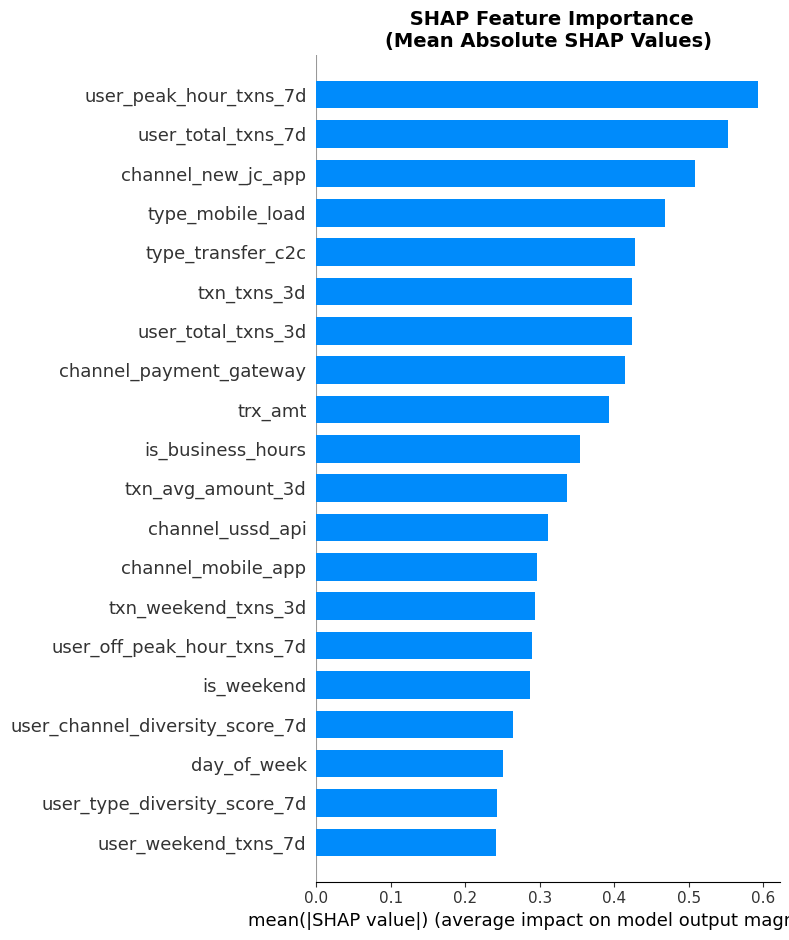

In [ ]:
explainer = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values = explainer.shap_values(X_shap)
plt.style.use('default')
print(f" Creating SHAP Feature Importance Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=top_30_features_by_variance, 
                  show=False, plot_type="bar")
plt.title(' SHAP Feature Importance\n(Mean Absolute SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Creating SHAP Summary Plot...


/tmp/ipykernel_3650597/168295226.py:5: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


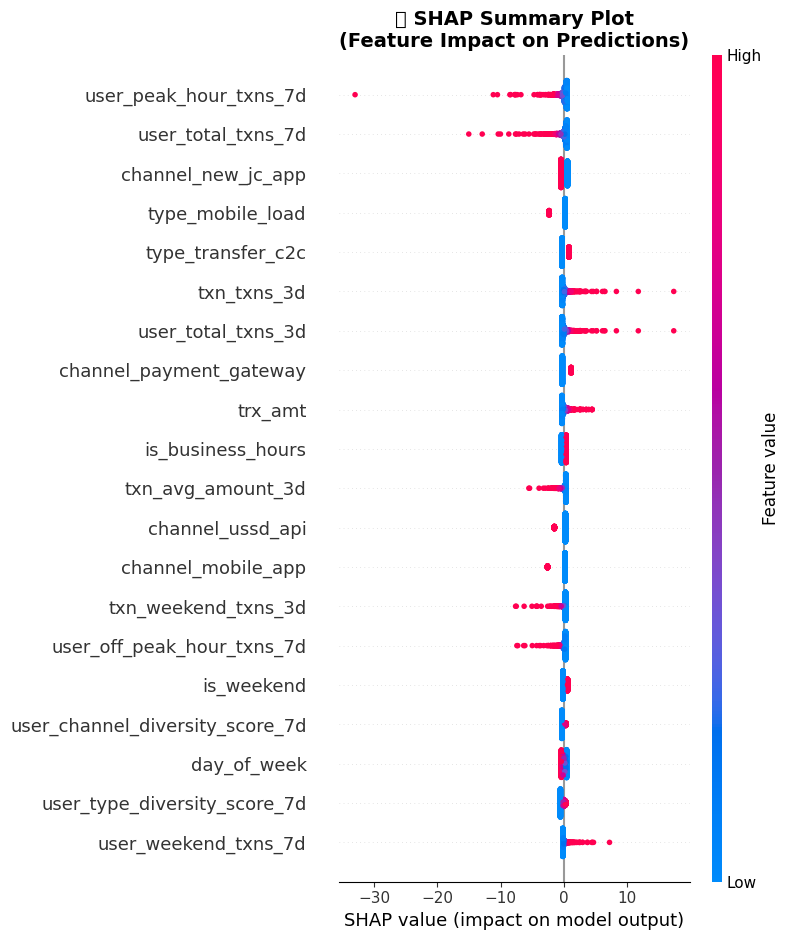

In [ ]:
print(f" Creating SHAP Summary Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=top_30_features_by_variance, show=False)
plt.title('🎯 SHAP Summary Plot\n(Feature Impact on Predictions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

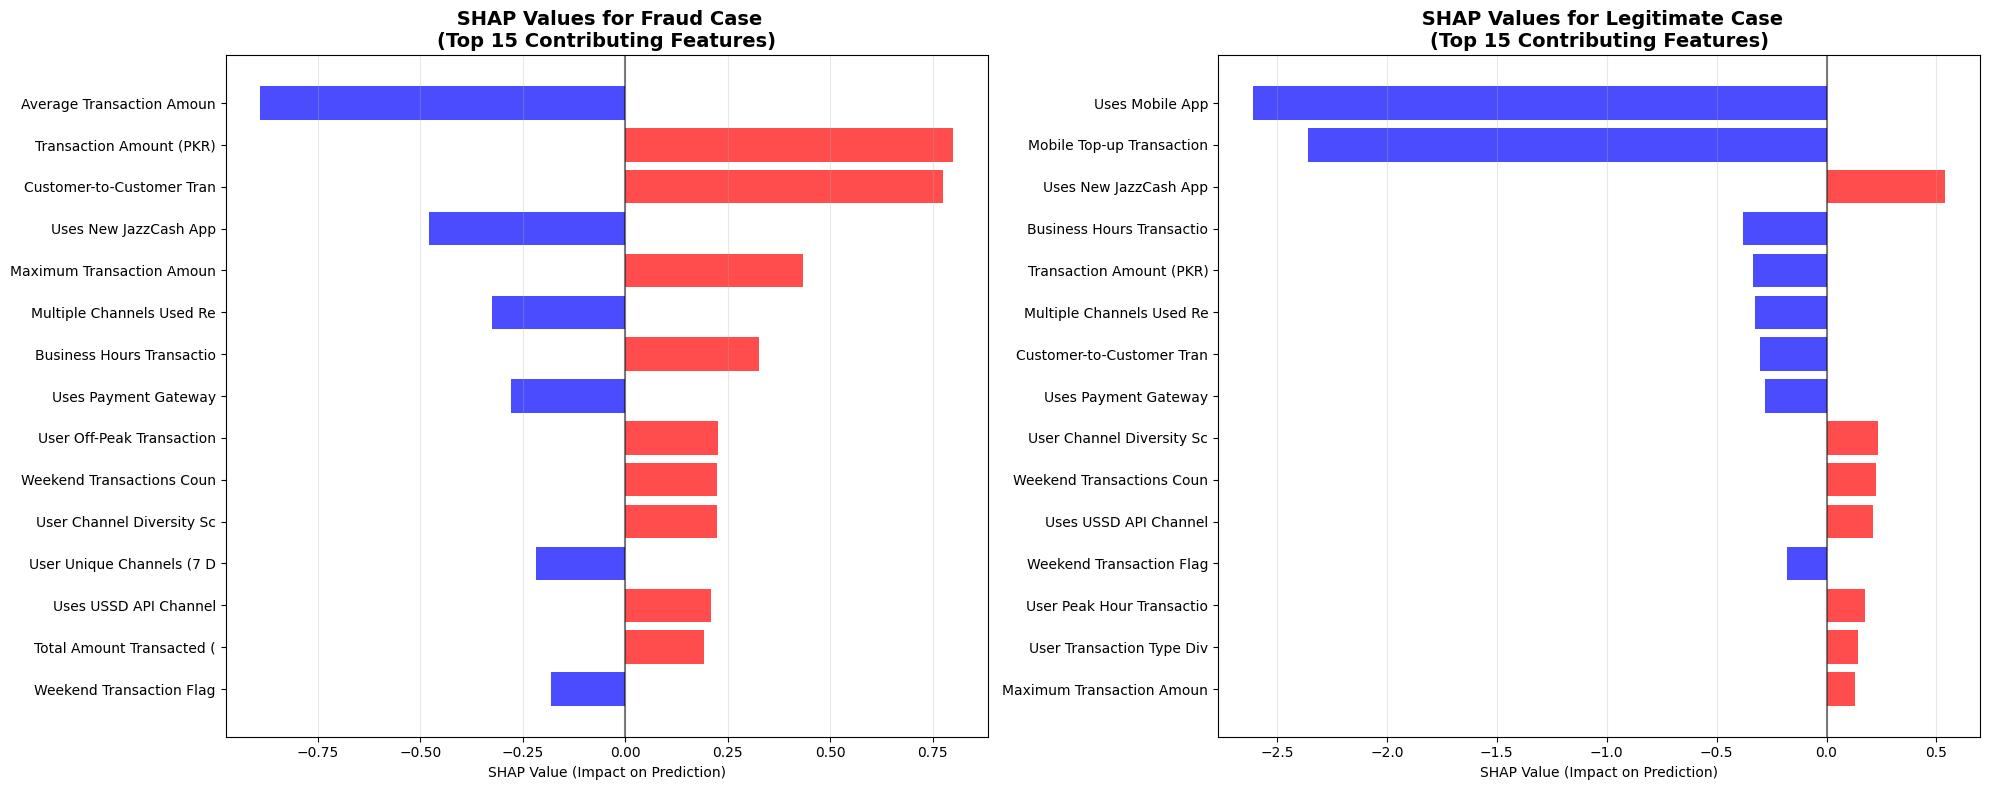

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fraud_indices = np.where(y_shap == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    base_value = explainer.expected_value
    shap_vals = shap_values[fraud_idx]
    sorted_indices = np.argsort(np.abs(shap_vals))[-15:]
    sorted_shap = shap_vals[sorted_indices]
    sorted_features = [top_30_features_by_variance[i] for i in sorted_indices]
    sorted_meaningful_names = [feature_name_mapping.get(f, f)[:25] for f in sorted_features]
    colors = ['red' if val > 0 else 'blue' for val in sorted_shap]
    ax1.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax1.set_yticks(range(len(sorted_shap)))
    ax1.set_yticklabels(sorted_meaningful_names, fontsize=10)
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax1.set_xlabel('SHAP Value (Impact on Prediction)')
    ax1.set_title(f' SHAP Values for Fraud Case\n(Top 15 Contributing Features)', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'No fraud cases in sample', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title(' SHAP Values for Fraud Case\n(No Fraud Cases Available)', fontsize=14, fontweight='bold')

legit_indices = np.where(y_shap == 0)[0]
if len(legit_indices) > 0:
    legit_idx = legit_indices[0]
    
    base_value = explainer.expected_value
    shap_vals = shap_values[legit_idx]
    feature_vals = X_shap[legit_idx]
    
    sorted_indices = np.argsort(np.abs(shap_vals))[-15:]  # Top 15
    sorted_shap = shap_vals[sorted_indices]
    sorted_features = [top_30_features_by_variance[i] for i in sorted_indices]
    sorted_meaningful_names = [feature_name_mapping.get(f, f)[:25] for f in sorted_features]
    
    colors = ['red' if val > 0 else 'blue' for val in sorted_shap]
    ax2.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(sorted_shap)))
    ax2.set_yticklabels(sorted_meaningful_names, fontsize=10)
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('SHAP Value (Impact on Prediction)')
    ax2.set_title(f' SHAP Values for Legitimate Case\n(Top 15 Contributing Features)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No legitimate cases in sample', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title(' SHAP Values for Legitimate Case\n(No Legitimate Cases Available)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
